In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib
import plotly.express as px
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
matplotlib.rcParams.update(new_rc_params)
matplotlib.rcParams['pdf.fonttype'] = 42 

In [2]:
arabi_genes = pd.read_csv('/vault/transfer/passala/Module_paper_data/Brome_soybean_flooding_stress/Ortho_vs_gene_files/brome_gene_results.csv', index_col= 0)
arabi_ortho = pd.read_csv('/vault/transfer/passala/Module_paper_data/Brome_soybean_flooding_stress/Ortho_vs_gene_files/brome_ortho_trimmed_out_2_gene_families.csv', index_col= 0)
tomato_genes = pd.read_csv('/vault/transfer/passala/Module_paper_data/Brome_soybean_flooding_stress/Ortho_vs_gene_files/soybean_gene_results.csv', index_col= 0)
tomato_ortho = pd.read_csv('/vault/transfer/passala/Module_paper_data/Brome_soybean_flooding_stress/Ortho_vs_gene_files/soybean_ortho_trimmed_out_2_gene_families.csv', index_col= 0)

In [3]:
log_fc_change_evaluation_value = 1.5
log_fc_change_evaluation_value_negative = -1*log_fc_change_evaluation_value

In [4]:
tomato_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10009at3193,173.000256,0.430426,0.242454,1.775288,7.585033e-02,1.273003e-01
10092at3193,260.781062,0.519181,0.152998,3.393376,6.903678e-04,1.904852e-03
10147at3193,426.832587,-0.208953,0.141672,-1.474906,1.402377e-01,2.135465e-01
10228at3193,1646.869190,0.430478,0.156549,2.749803,5.963109e-03,1.356038e-02
10488at3193,394.770119,-0.994054,0.353945,-2.808500,4.977288e-03,1.150893e-02
...,...,...,...,...,...,...
9828at3193,429.031629,0.235979,0.152430,1.548116,1.215944e-01,1.902134e-01
9836at3193,264.174162,-0.414411,0.164656,-2.516825,1.184175e-02,2.507813e-02
9877at3193,474.015423,0.159871,0.173605,0.920888,3.571087e-01,4.580196e-01
9919at3193,461.925167,1.723904,0.188059,9.166842,4.870796e-20,7.829191e-19


In [5]:
trimmed_tomato_ortho = tomato_ortho.loc[tomato_ortho.index.isin(arabi_ortho.index)]
trimmed_arabi_ortho = arabi_ortho.loc[arabi_ortho.index.isin(trimmed_tomato_ortho.index)]


In [6]:
trimmed_arabi_ortho_named = trimmed_arabi_ortho.rename(columns = {'log2FoldChange':'Arabidopsis Log2FC'})
trimmed_tomato_ortho_named = trimmed_tomato_ortho.rename(columns = {'log2FoldChange':'Tomato Log2FC'})



In [7]:
merged_ortho_df = trimmed_arabi_ortho_named[['Arabidopsis Log2FC']].merge(right = trimmed_tomato_ortho_named, left_index= True, right_index = True)

In [8]:
merged_ortho_df

,Arabidopsis Log2FC,baseMean,Tomato Log2FC,lfcSE,stat,pvalue,padj
10772at3193,-0.823722,1432.514851,0.141324,0.096395,1.466092,1.426233e-01,2.167360e-01
10950at3193,0.609257,1504.589985,0.768931,0.130069,5.911713,3.385688e-09,2.105629e-08
109808at3193,-0.234491,81.928350,-0.724654,0.321686,-2.252679,2.427938e-02,4.721166e-02
109895at3193,-0.965963,34.756034,0.141902,0.317448,0.447008,6.548695e-01,7.391474e-01
109989at3193,-0.085234,438.013716,-0.142711,0.125299,-1.138971,2.547153e-01,3.491290e-01
...,...,...,...,...,...,...,...
9592at3193,-0.088107,714.567831,-1.004056,0.114738,-8.750851,2.117501e-18,3.047359e-17
9601at3193,0.012267,555.019544,-0.245262,0.172802,-1.419321,1.558055e-01,2.330127e-01
9609at3193,-2.083956,180.978946,-1.038789,0.284603,-3.649957,2.622840e-04,7.823873e-04
9789at3193,-0.323663,642.577002,-0.762086,0.124106,-6.140625,8.219721e-10,5.552505e-09


In [9]:
log_fc_change_evaluation_value

1.5

In [10]:
trimmed_tomato_ortho.loc[(trimmed_tomato_ortho['log2FoldChange'] < -1.58) & ( trimmed_tomato_ortho['log2FoldChange'] > -1.6)] 

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
115851at3193,520.077944,-1.582375,0.197729,-8.002732,1.216890e-15,1.397793e-14
122578at3193,214.363107,-1.589639,0.467272,-3.401956,6.690539e-04,1.851761e-03
128908at3193,236.776253,-1.590202,0.229123,-6.940385,3.910315e-12,3.325070e-11
135291at3193,90.106807,-1.586768,0.231070,-6.867055,6.554071e-12,5.489572e-11
136145at3193,106.519029,-1.588392,0.369731,-4.296070,1.738528e-05,6.436298e-05
592952at3193,73.678490,-1.597029,0.250477,-6.375957,1.818236e-10,1.324334e-09
871418at3193,1937.956232,-1.580297,0.214375,-7.371667,1.685080e-13,1.607210e-12


In [11]:
trimmed_arabi_ortho.loc[trimmed_arabi_ortho['log2FoldChange'] >2.5]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
122578at3193,296.012809,6.213118,0.354730,17.515062,1.099666e-68,1.767502e-66
43702at3193,2745.817126,5.935614,0.198147,29.955641,3.715224e-197,1.552592e-193
76646at3193,701.537736,5.496071,0.208289,26.386819,1.941229e-153,2.028099e-150
869048at3193,3113.693126,3.851692,0.199041,19.351267,1.988940e-83,4.155890e-81
873403at3193,2976.638294,10.570167,0.388469,27.209834,4.968458e-163,6.921063e-160
874981at3193,35.266932,2.874140,0.409719,7.014905,2.301049e-12,1.789248e-11
886306at3193,33.087139,3.897668,0.549170,7.097377,1.271465e-12,1.015957e-11
886899at3193,4930.559412,2.629330,0.176082,14.932448,2.026876e-50,1.925072e-48


In [12]:
merged_ortho_df_mod= merged_ortho_df.reset_index()
merged_ortho_df_mod

,index,Arabidopsis Log2FC,baseMean,Tomato Log2FC,lfcSE,stat,pvalue,padj
0,10772at3193,-0.823722,1432.514851,0.141324,0.096395,1.466092,1.426233e-01,2.167360e-01
1,10950at3193,0.609257,1504.589985,0.768931,0.130069,5.911713,3.385688e-09,2.105629e-08
2,109808at3193,-0.234491,81.928350,-0.724654,0.321686,-2.252679,2.427938e-02,4.721166e-02
3,109895at3193,-0.965963,34.756034,0.141902,0.317448,0.447008,6.548695e-01,7.391474e-01
4,109989at3193,-0.085234,438.013716,-0.142711,0.125299,-1.138971,2.547153e-01,3.491290e-01
...,...,...,...,...,...,...,...,...
3067,9592at3193,-0.088107,714.567831,-1.004056,0.114738,-8.750851,2.117501e-18,3.047359e-17
3068,9601at3193,0.012267,555.019544,-0.245262,0.172802,-1.419321,1.558055e-01,2.330127e-01
3069,9609at3193,-2.083956,180.978946,-1.038789,0.284603,-3.649957,2.622840e-04,7.823873e-04
3070,9789at3193,-0.323663,642.577002,-0.762086,0.124106,-6.140625,8.219721e-10,5.552505e-09


In [13]:
fig = px.scatter(merged_ortho_df_mod, x='Tomato Log2FC', y='Arabidopsis Log2FC', 

                 hover_data=['Tomato Log2FC', 'Arabidopsis Log2FC', 'index',], # Data to show on hover
                 )

fig.update_layout(
    xaxis_title='Orthogroup-wise log2-fold change in soybean Drought',
    yaxis_title='Orthogroup-wise log2-fold change in brome Drought',)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([['10772at3193'],
                                   ['10950at3193'],
                                   ['109808at3193'],
                                   ...,
                                   ['9609at3193'],
                                   ['9789at3193'],
                                   ['9942at3193']], shape=(3072, 1), dtype=object),
              'hovertemplate': ('Tomato Log2FC=%{x}<br>Arabidop' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': '',
              'marker': {'color': '#636efa', 'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'x': {'bdata': ('QKLEIekWwj+vXLFyFZvoP0tsiW9eMO' ... 'IIl+Ge8L/CCYZBAmPov24eyZj3Wcw/'),
                    'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': ('CGfSJu9b6r/dGRKFB3/jP0sT4UfPA8' ... 'xIW/GrAMDxPgHA5LbUv7cor5Mu7ci/'),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y',
                         'domain': [0.0, 1.0],
                         'title': {'text': 'Orthogroup-wise log2-fold change in soybean Drought'}},
               'yaxis': {'anchor': 'x',
                         'domain': [0.0, 1.0],
                         'title': {'text': 'Orthogroup-wise log2-fold change in brome Drought'}}}
})

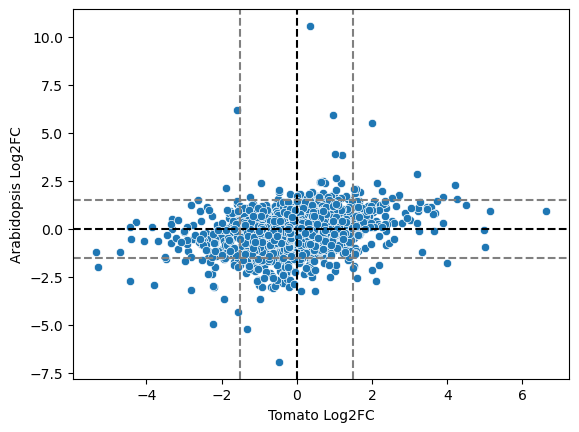

In [14]:
sns.scatterplot(data = merged_ortho_df, x ='Tomato Log2FC', y = 'Arabidopsis Log2FC' )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(x =log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(y =log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(x =log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(y =log_fc_change_evaluation_value_negative, color="grey", linestyle="--")

Text(0, 0.5, 'Orthogroup-wise log2-fold change in \n brome Drought')

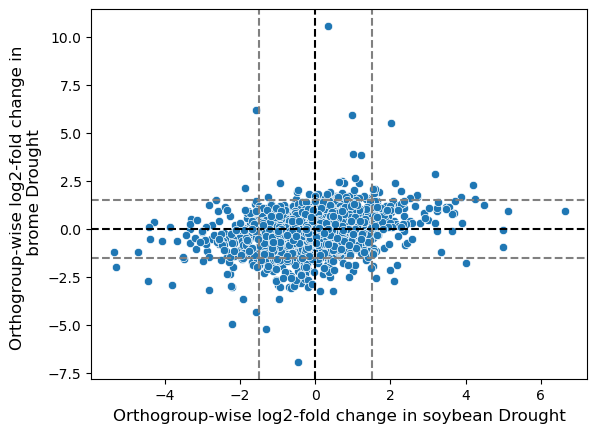

In [15]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.xlabel("Orthogroup-wise log2-fold change in soybean Drought", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in \n brome Drought", fontsize = 12)

In [16]:
trimmed_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10772at3193,1253.808835,-0.823722,0.112959,-7.292232,3.048614e-13,2.621432e-12
10950at3193,2602.895885,0.609257,0.090454,6.735537,1.633256e-11,1.160778e-10
109808at3193,415.334713,-0.234491,0.124907,-1.877332,6.047254e-02,9.485954e-02
109895at3193,29.465058,-0.965963,0.410548,-2.352859,1.862971e-02,3.354311e-02
109989at3193,102.457293,-0.085234,0.206198,-0.413361,6.793419e-01,7.352940e-01
...,...,...,...,...,...,...
9592at3193,677.363236,-0.088107,0.105964,-0.831483,4.057006e-01,4.811075e-01
9601at3193,647.889907,0.012267,0.143439,0.085524,9.318447e-01,9.467977e-01
9609at3193,304.540836,-2.083956,0.221131,-9.424067,4.339454e-21,8.095794e-20
9789at3193,506.494370,-0.323663,0.111529,-2.902062,3.707147e-03,7.840165e-03


In [17]:
all(trimmed_arabi_ortho.index == trimmed_tomato_ortho.index)

True

In [18]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]

In [19]:
merged_result['Classification'] = 'Non-substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

/tmp/ipykernel_2321377/2994845458.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
/tmp/ipykernel_2321377/2994845458.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because

Text(0, 0.5, 'Orthogroup-wise log2-fold change in brome Drought')

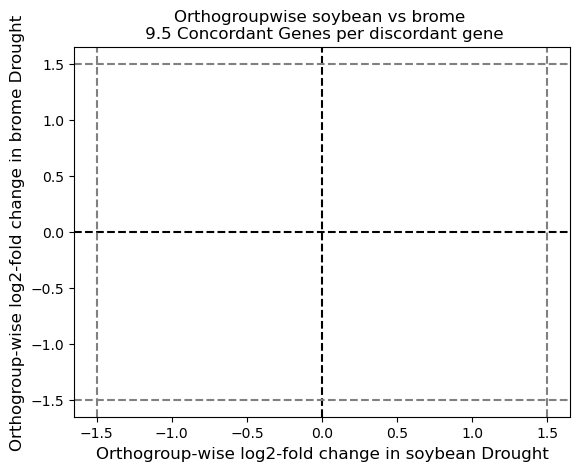

In [20]:
sns.scatterplot(data = merged_result.loc[merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 10)
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.title('Orthogroupwise soybean vs brome \n 9.5 Concordant Genes per discordant gene')
plt.xlabel("Orthogroup-wise log2-fold change in soybean Drought", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in brome Drought", fontsize = 12)

Text(0, 0.5, 'Family-level log2-fold change in \n Glycine max under flooding stress')

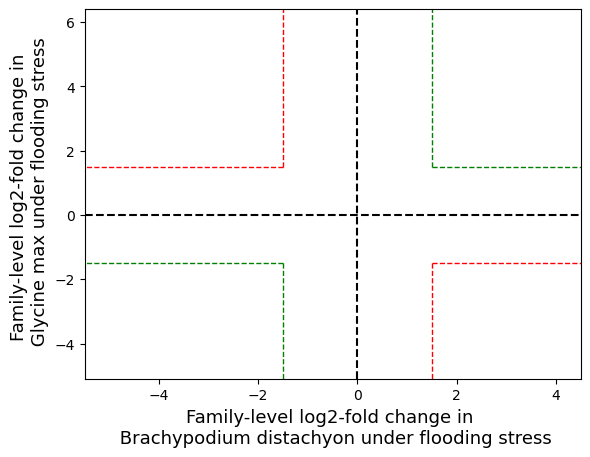

In [21]:
sns.scatterplot(data = merged_result.loc[merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 15, edgecolor = 'none')
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")

plt.xlim(-5.5,4.5)
plt.ylim(-5.1,6.4)
# Top left quadrant - red
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value,20], color = 'r', linestyle = '--',linewidth=1)
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'r', linestyle = '--', linewidth=1)

# Top right quadrant - green
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'g', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value,20], color = 'g', linestyle = '--', linewidth=1)

# Bottom left quadrant - green
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value_negative,-20], color = 'g', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'g', linestyle = '--', linewidth=1)

# Bottom right quadrant - red
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'r', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value_negative,-20], color = 'r', linestyle = '--', linewidth=1)
#plt.title('Genewise potato vs medicago \n 3.3 Concordant Genes per Discordant Gene')

plt.xlabel("Family-level log2-fold change in \n Brachypodium distachyon under flooding stress", fontsize = 13)
plt.ylabel("Family-level log2-fold change in \n Glycine max under flooding stress", fontsize = 13)
#plt.savefig('/data/passala/Plots_for_projects/Cross_species_go_groups/brome_soybean_example/orthowise_stress.svg',dpi = 1200)

In [22]:
merged_ortho_df_mod = merged_ortho_df_mod.merge(right = merged_result[['Classification']], left_index= True, right_index = True)
merged_ortho_df_mod

,index,Arabidopsis Log2FC,baseMean,Tomato Log2FC,lfcSE,stat,pvalue,padj,Classification
0,10772at3193,-0.823722,1432.514851,0.141324,0.096395,1.466092,1.426233e-01,2.167360e-01,Non-substantial
1,10950at3193,0.609257,1504.589985,0.768931,0.130069,5.911713,3.385688e-09,2.105629e-08,Non-substantial
2,109808at3193,-0.234491,81.928350,-0.724654,0.321686,-2.252679,2.427938e-02,4.721166e-02,Non-substantial
3,109895at3193,-0.965963,34.756034,0.141902,0.317448,0.447008,6.548695e-01,7.391474e-01,Non-substantial
4,109989at3193,-0.085234,438.013716,-0.142711,0.125299,-1.138971,2.547153e-01,3.491290e-01,Non-substantial
...,...,...,...,...,...,...,...,...,...
3067,9592at3193,-0.088107,714.567831,-1.004056,0.114738,-8.750851,2.117501e-18,3.047359e-17,Non-substantial
3068,9601at3193,0.012267,555.019544,-0.245262,0.172802,-1.419321,1.558055e-01,2.330127e-01,Non-substantial
3069,9609at3193,-2.083956,180.978946,-1.038789,0.284603,-3.649957,2.622840e-04,7.823873e-04,Non-substantial
3070,9789at3193,-0.323663,642.577002,-0.762086,0.124106,-6.140625,8.219721e-10,5.552505e-09,Non-substantial


In [23]:
merged_ortho_df_mod

,index,Arabidopsis Log2FC,baseMean,Tomato Log2FC,lfcSE,stat,pvalue,padj,Classification
0,10772at3193,-0.823722,1432.514851,0.141324,0.096395,1.466092,1.426233e-01,2.167360e-01,Non-substantial
1,10950at3193,0.609257,1504.589985,0.768931,0.130069,5.911713,3.385688e-09,2.105629e-08,Non-substantial
2,109808at3193,-0.234491,81.928350,-0.724654,0.321686,-2.252679,2.427938e-02,4.721166e-02,Non-substantial
3,109895at3193,-0.965963,34.756034,0.141902,0.317448,0.447008,6.548695e-01,7.391474e-01,Non-substantial
4,109989at3193,-0.085234,438.013716,-0.142711,0.125299,-1.138971,2.547153e-01,3.491290e-01,Non-substantial
...,...,...,...,...,...,...,...,...,...
3067,9592at3193,-0.088107,714.567831,-1.004056,0.114738,-8.750851,2.117501e-18,3.047359e-17,Non-substantial
3068,9601at3193,0.012267,555.019544,-0.245262,0.172802,-1.419321,1.558055e-01,2.330127e-01,Non-substantial
3069,9609at3193,-2.083956,180.978946,-1.038789,0.284603,-3.649957,2.622840e-04,7.823873e-04,Non-substantial
3070,9789at3193,-0.323663,642.577002,-0.762086,0.124106,-6.140625,8.219721e-10,5.552505e-09,Non-substantial


In [24]:
fig = px.scatter(merged_ortho_df_mod.loc[merged_ortho_df_mod['Classification'] == "Substantial"], x='Tomato Log2FC', y='Arabidopsis Log2FC', 

                 hover_data=['Tomato Log2FC', 'Arabidopsis Log2FC', 'index',], # Data to show on hover
                 )

fig.update_layout(
    xaxis_title='Orthogroup-wise log2-fold change in soybean Drought',
    yaxis_title='Orthogroup-wise log2-fold change in brome Drought',)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([], shape=(0, 1), dtype=object),
              'hovertemplate': ('Tomato Log2FC=%{x}<br>Arabidop' ... '{customdata[0]}<extra></extra>'),
              'legendgroup': '',
              'marker': {'color': '#636efa', 'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': array([], dtype=float64),
              'xaxis': 'x',
              'y': array([], dtype=float64),
              'yaxis': 'y'}],
    'layout': {'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y',
                         'domain': [0.0, 1.0],
                         'title': {'text': 'Orthogroup-wise log2-fold change in soybean Drought'}},
               'yaxis': {'anchor': 'x',
                         'domain': [0.0, 1.0],
                         'title': {'text': 'Orthogroup-wise log2-fold change in brome Drought'}}}
})

In [25]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

5.125

In [26]:
discord_bottom

,Tomato,Arabi
29,1.522077,-1.928150
1087,2.185773,-1.869063
1904,2.106442,-2.737350
2050,1.605068,-2.564105
2297,1.989399,-2.161249
2540,3.997364,-1.772877


In [27]:
discord_top

,Tomato,Arabi
295,-1.589639,6.213118
976,-1.881753,2.115764


In [28]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])
pos_thresh = 1
neg_thresh = 1
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

0.9078776041666666
0.9078776041666666
0.9078776041666666
0.9078776041666666


In [29]:
arabi_disconcordant_change

,Tomato,Arabi
10,1.217503,-0.040479
29,1.522077,-1.928150
34,1.672570,-0.200683
39,1.012039,0.363159
40,2.377045,-0.833857
...,...,...
2993,1.393896,-0.661331
2995,1.239317,-0.283170
2997,5.132424,0.943523
3019,2.267969,0.105545


In [30]:
tomato_any_change

,Tomato,Arabi
0,0.141324,-0.823722
1,0.768931,0.609257
2,-0.724654,-0.234491
3,0.141902,-0.965963
4,-0.142711,-0.085234
...,...,...
3067,-1.004056,-0.088107
3068,-0.245262,0.012267
3069,-1.038789,-2.083956
3070,-0.762086,-0.323663


In [31]:
tomato_concordant_change

,Tomato,Arabi
0,0.141324,-0.823722
1,0.768931,0.609257
2,-0.724654,-0.234491
3,0.141902,-0.965963
4,-0.142711,-0.085234
...,...,...
3067,-1.004056,-0.088107
3068,-0.245262,0.012267
3069,-1.038789,-2.083956
3070,-0.762086,-0.323663


In [32]:
arabidopsis_tomato_nm = pd.read_csv('/vault/transfer/passala/OrthoDB_data/V_11_pairwise_maps_fixed_problem_species/soybean_to_brome_ortholog_NM.csv')

In [33]:
arabidopsis_tomato_nm

,soybean OrthoGene,brome OrthoGene,Orthogroup,soybean Symbol,brome Symbol
0,3847_0:001d45,15368_0:004b9d,10009at3193,GLYMA_04G021200,LOC112268890
1,3847_0:002e23,15368_0:004b9d,10009at3193,GLYMA_06G021400,LOC112268890
2,3847_0:007f21,15368_0:004b9d,10009at3193,GLYMA_14G221800,LOC112268890
3,3847_0:009b10,15368_0:004b9d,10009at3193,GLYMA_17G260700,LOC112268890
4,3847_0:0022f2,15368_0:002acb,10092at3193,GLYMA_04G056600,LOC100824059
...,...,...,...,...,...
78753,3847_0:0048d1,15368_0:002eb5,9942at3193,GLYMA_08G068100,LOC100830624
78754,3847_0:00255c,15368_0:002fc6,9942at3193,LOC100810943,LOC100830933
78755,3847_0:0039db,15368_0:002fc6,9942at3193,GLYMA_07G181700,LOC100830933
78756,3847_0:00489a,15368_0:002fc6,9942at3193,GLYMA_08G126200,LOC100830933


In [34]:
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'brome Symbol',)
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'soybean Symbol',)
arabidopsis_tomato_nm

,soybean OrthoGene,brome OrthoGene,Orthogroup,soybean Symbol,brome Symbol
0,3847_0:001d45,15368_0:004b9d,10009at3193,GLYMA_04G021200,LOC112268890
4,3847_0:0022f2,15368_0:002acb,10092at3193,GLYMA_04G056600,LOC100824059
7,3847_0:001acf,15368_0:000aa9,10147at3193,GLYMA_03G107300,LOC100833000
12,3847_0:002544,15368_0:002644,10228at3193,GLYMA_05G233100,LOC100845189
14,3847_0:00393f,15368_0:002661,10238at3193,GLYMA_07G037800,LOC100843355
...,...,...,...,...,...
78717,3847_0:0028b8,15368_0:002f8c,9789at3193,LOC100796401,LOC100829470
78733,3847_0:001b3a,15368_0:005266,9828at3193,GLYMA_04G175400,LOC100832383
78736,3847_0:000e97,15368_0:00447e,9877at3193,GLYMA_02G288500,LOC100838601
78740,3847_0:005414,15368_0:001d76,9919at3193,GLYMA_09G084600,LOC100826227


In [35]:
arabi_genes_trimmed = arabi_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[['soybean Symbol','brome Symbol']], right_on= 'brome Symbol')
arabi_genes_trimmed = arabi_genes_trimmed.drop_duplicates(subset = 'brome Symbol', keep = False)
arabi_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,soybean Symbol,brome Symbol
24009,23.936160,3.752967,0.582680,6.440867,1.187927e-10,8.209202e-10,GLYMA_08G247900,LOC100834957
75178,82.992119,-1.024906,0.271418,-3.776114,1.592942e-04,4.399304e-04,GLYMA_14G133100,LOC100844744
59066,1116.361775,0.079793,0.117593,0.678552,4.974215e-01,5.731693e-01,GLYMA_06G269900,LOC100842425
40411,1835.172729,-0.043313,0.114516,-0.378224,7.052646e-01,7.624134e-01,GSTT2,LOC100842114
77984,1619.499356,0.036739,0.111469,0.329591,7.417090e-01,7.931762e-01,GLYMA_09G136800,LOC100825490
...,...,...,...,...,...,...,...,...
54747,383.493361,-0.557131,0.142778,-3.902089,9.536616e-05,2.733387e-04,LOC100500664,LOC100839656
27299,879.417618,-1.742678,0.141708,-12.297706,9.318315e-35,5.246888e-33,LOC100793945,LOC100846269
45655,315.018439,0.042993,0.150568,0.285541,7.752298e-01,8.209775e-01,GLYMA_08G002800,LOC100846573
4446,201.259418,-1.296853,0.194851,-6.655620,2.821078e-11,2.106196e-10,GLYMA_04G243800,LOC100822302


In [36]:
arabidopsis_tomato_nm

,soybean OrthoGene,brome OrthoGene,Orthogroup,soybean Symbol,brome Symbol
0,3847_0:001d45,15368_0:004b9d,10009at3193,GLYMA_04G021200,LOC112268890
4,3847_0:0022f2,15368_0:002acb,10092at3193,GLYMA_04G056600,LOC100824059
7,3847_0:001acf,15368_0:000aa9,10147at3193,GLYMA_03G107300,LOC100833000
12,3847_0:002544,15368_0:002644,10228at3193,GLYMA_05G233100,LOC100845189
14,3847_0:00393f,15368_0:002661,10238at3193,GLYMA_07G037800,LOC100843355
...,...,...,...,...,...
78717,3847_0:0028b8,15368_0:002f8c,9789at3193,LOC100796401,LOC100829470
78733,3847_0:001b3a,15368_0:005266,9828at3193,GLYMA_04G175400,LOC100832383
78736,3847_0:000e97,15368_0:00447e,9877at3193,GLYMA_02G288500,LOC100838601
78740,3847_0:005414,15368_0:001d76,9919at3193,GLYMA_09G084600,LOC100826227


In [37]:
tomato_genes.head(50)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
GLYMA_01G000322,22.036269,0.274457,0.476149,0.576410,5.643378e-01,6.539785e-01
GLYMA_01G000400,476.034338,0.037230,0.136237,0.273276,7.846409e-01,8.399009e-01
GLYMA_01G000600,368.857765,0.416337,0.144185,2.887511,3.883026e-03,9.043730e-03
GLYMA_01G000900,728.885736,0.680659,0.178505,3.813113,1.372273e-04,4.327456e-04
GLYMA_01G001000,442.703824,0.402593,0.168362,2.391231,1.679198e-02,3.345424e-02
GLYMA_01G001100,310.848726,-1.860885,0.207948,-8.948799,3.593697e-19,5.927628e-18
GLYMA_01G001200,116.511478,-0.951458,0.292023,-3.258158,1.121378e-03,2.948588e-03
GLYMA_01G001300,2248.774697,-0.508059,0.206564,-2.459568,1.391045e-02,2.835089e-02
GLYMA_01G001325,62.472507,0.251939,0.330521,0.762247,4.459127e-01,5.432384e-01
GLYMA_01G001600,312.141059,0.567635,0.171457,3.310661,9.307599e-04,2.492316e-03


In [38]:
tomato_genes_trimmed = tomato_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[['soybean Symbol','brome Symbol']], right_on= 'soybean Symbol')
#tomato_genes_trimmed = tomato_genes_trimmed.drop_duplicates(subset = 'brome Symbol', keep = False)
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,soybean Symbol,brome Symbol
1037,476.034338,0.037230,0.136237,0.273276,7.846409e-01,8.399009e-01,GLYMA_01G000400,LOC100846077
10349,442.703824,0.402593,0.168362,2.391231,1.679198e-02,3.345424e-02,GLYMA_01G001000,LOC100835748
22007,310.848726,-1.860885,0.207948,-8.948799,3.593697e-19,5.927628e-18,GLYMA_01G001100,LOC100840646
59036,116.511478,-0.951458,0.292023,-3.258158,1.121378e-03,2.948588e-03,GLYMA_01G001200,LOC100843002
21433,2248.774697,-0.508059,0.206564,-2.459568,1.391045e-02,2.835089e-02,GLYMA_01G001300,LOC100835163
...,...,...,...,...,...,...,...,...
72102,409.430588,0.241802,0.199745,1.210555,2.260660e-01,3.140477e-01,GLYMA_20G248800,LOC100829027
29573,499.095619,0.025827,0.146622,0.176145,8.601802e-01,8.976651e-01,GLYMA_20G249100,LOC100832887
37403,1065.537055,0.557655,0.133712,4.170563,3.038481e-05,1.079335e-04,GLYMA_20G249400,LOC100843193
42491,1703.746016,0.582504,0.117478,4.958400,7.107616e-07,3.300776e-06,GLYMA_20G249700,LOC100828030


In [39]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,soybean Symbol,brome Symbol
1037,476.034338,0.037230,0.136237,0.273276,7.846409e-01,8.399009e-01,GLYMA_01G000400,LOC100846077
10349,442.703824,0.402593,0.168362,2.391231,1.679198e-02,3.345424e-02,GLYMA_01G001000,LOC100835748
22007,310.848726,-1.860885,0.207948,-8.948799,3.593697e-19,5.927628e-18,GLYMA_01G001100,LOC100840646
59036,116.511478,-0.951458,0.292023,-3.258158,1.121378e-03,2.948588e-03,GLYMA_01G001200,LOC100843002
21433,2248.774697,-0.508059,0.206564,-2.459568,1.391045e-02,2.835089e-02,GLYMA_01G001300,LOC100835163
...,...,...,...,...,...,...,...,...
72102,409.430588,0.241802,0.199745,1.210555,2.260660e-01,3.140477e-01,GLYMA_20G248800,LOC100829027
29573,499.095619,0.025827,0.146622,0.176145,8.601802e-01,8.976651e-01,GLYMA_20G249100,LOC100832887
37403,1065.537055,0.557655,0.133712,4.170563,3.038481e-05,1.079335e-04,GLYMA_20G249400,LOC100843193
42491,1703.746016,0.582504,0.117478,4.958400,7.107616e-07,3.300776e-06,GLYMA_20G249700,LOC100828030


In [40]:
arabi_genes_trimmed = arabi_genes_trimmed.loc[arabi_genes_trimmed['brome Symbol'].isin(tomato_genes_trimmed['brome Symbol'])]
tomato_genes_trimmed = tomato_genes_trimmed.loc[tomato_genes_trimmed['soybean Symbol'].isin(arabi_genes_trimmed['soybean Symbol'])]


In [41]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,soybean Symbol,brome Symbol
1037,476.034338,0.037230,0.136237,0.273276,7.846409e-01,8.399009e-01,GLYMA_01G000400,LOC100846077
10349,442.703824,0.402593,0.168362,2.391231,1.679198e-02,3.345424e-02,GLYMA_01G001000,LOC100835748
22007,310.848726,-1.860885,0.207948,-8.948799,3.593697e-19,5.927628e-18,GLYMA_01G001100,LOC100840646
59036,116.511478,-0.951458,0.292023,-3.258158,1.121378e-03,2.948588e-03,GLYMA_01G001200,LOC100843002
55501,312.141059,0.567635,0.171457,3.310661,9.307599e-04,2.492316e-03,GLYMA_01G001600,LOC100833468
...,...,...,...,...,...,...,...,...
72102,409.430588,0.241802,0.199745,1.210555,2.260660e-01,3.140477e-01,GLYMA_20G248800,LOC100829027
29573,499.095619,0.025827,0.146622,0.176145,8.601802e-01,8.976651e-01,GLYMA_20G249100,LOC100832887
37403,1065.537055,0.557655,0.133712,4.170563,3.038481e-05,1.079335e-04,GLYMA_20G249400,LOC100843193
42491,1703.746016,0.582504,0.117478,4.958400,7.107616e-07,3.300776e-06,GLYMA_20G249700,LOC100828030


In [42]:
tomato_genes_trimmed = (tomato_genes_trimmed.set_index('brome Symbol')
          .reindex(arabi_genes_trimmed.set_index('brome Symbol').index)
          .reset_index()
       )

In [43]:
tomato_genes_trimmed

,brome Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,soybean Symbol
0,LOC100844744,257.558000,0.861340,0.206827,4.164547,3.119710e-05,1.106143e-04,GLYMA_14G133100
1,LOC100825490,589.678017,-0.144485,0.148426,-0.973447,3.303311e-01,4.279740e-01,GLYMA_09G136800
2,LOC100837010,45.066828,-0.067016,0.377704,-0.177431,8.591699e-01,8.967462e-01,GLYMA_04G239600
3,LOC100837316,38.466531,0.596413,0.334033,1.785493,7.418134e-02,1.219858e-01,GLYMA_10G230100
4,LOC100821843,558.143700,0.065794,0.165025,0.398694,6.901184e-01,7.632006e-01,GLYMA_09G224100
...,...,...,...,...,...,...,...,...
7585,LOC100838433,1361.733530,0.599615,0.155423,3.857952,1.143409e-04,3.660857e-04,GLYMA_10G283400
7586,LOC100845152,1331.703355,-1.570305,0.328035,-4.787008,1.692865e-06,7.406765e-06,GLYMA_13G357200
7587,LOC100839049,849.147630,0.173071,0.121378,1.425885,1.539015e-01,2.275662e-01,GLYMA_12G228700
7588,LOC100846573,187.993907,0.077090,0.196641,0.392035,6.950324e-01,7.671864e-01,GLYMA_08G002800


In [44]:
arabi_genes_trimmed = arabi_genes_trimmed.reset_index()

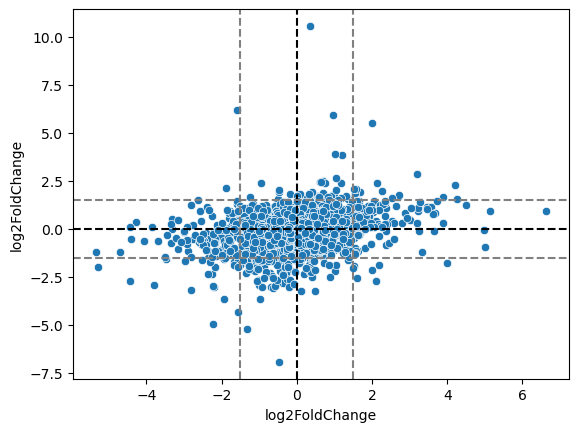

In [45]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")

Text(0, 0.5, 'Genewise log2-fold change in \n brome Drought')

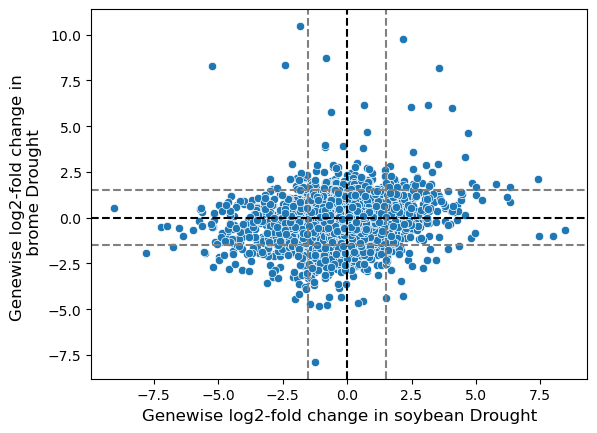

In [46]:
sns.scatterplot(x =tomato_genes_trimmed['log2FoldChange'], y = arabi_genes_trimmed['log2FoldChange'])
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.xlabel("Genewise log2-fold change in soybean Drought", fontsize = 12)
plt.ylabel("Genewise log2-fold change in \n brome Drought", fontsize = 12)

In [47]:
new_merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]

In [48]:
new_merged_result['Classification'] = 'Non-substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

/tmp/ipykernel_2321377/1856289886.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
/tmp/ipykernel_2321377/1856289886.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Ser

Text(0, 0.5, 'Genewise log2-fold change in Sorghum Drought')

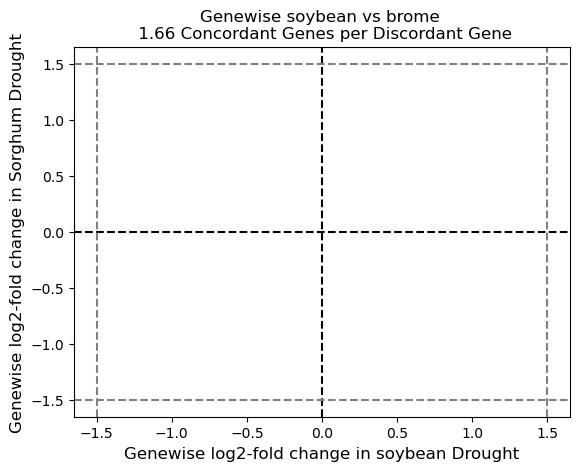

In [49]:
sns.scatterplot(data = new_merged_result.loc[new_merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 10 )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.title('Genewise soybean vs brome \n 1.66 Concordant Genes per Discordant Gene')
plt.xlabel("Genewise log2-fold change in soybean Drought", fontsize = 12)
plt.ylabel("Genewise log2-fold change in Sorghum Drought", fontsize = 12)

Text(0, 0.5, 'Gene-level log2-fold change in \n Glycine max under drought stress')

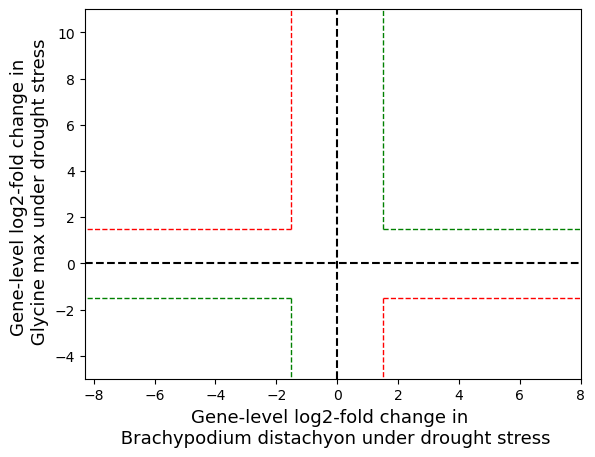

In [50]:
sns.scatterplot(data = new_merged_result.loc[new_merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 15, edgecolor = None )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
#plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
# Top left quadrant - red
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value,20], color = 'r', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'r', linestyle = '--', linewidth=1)

# Top right quadrant - green
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value,log_fc_change_evaluation_value], color = 'g', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value,20], color = 'g', linestyle = '--', linewidth=1)

# Bottom left quadrant - green
plt.plot([log_fc_change_evaluation_value_negative, log_fc_change_evaluation_value_negative],[log_fc_change_evaluation_value_negative,-20], color = 'g', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value_negative, -20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'g', linestyle = '--', linewidth=1)

# Bottom right quadrant - red
plt.plot([log_fc_change_evaluation_value, 20],[log_fc_change_evaluation_value_negative,log_fc_change_evaluation_value_negative], color = 'r', linestyle = '--', linewidth=1)
plt.plot([log_fc_change_evaluation_value, log_fc_change_evaluation_value],[log_fc_change_evaluation_value_negative,-20], color = 'r', linestyle = '--', linewidth=1)
#plt.title('Genewise potato vs medicago \n 3.3 Concordant Genes per Discordant Gene')
plt.xlim(-8.3,8)
plt.ylim(-5,11)
plt.xlabel("Gene-level log2-fold change in \n Brachypodium distachyon under drought stress", fontsize = 13)
plt.ylabel("Gene-level log2-fold change in \n Glycine max under drought stress", fontsize = 13)
#plt.savefig('/data/passala/Plots_for_projects/Cross_species_go_groups/brome_soybean_example/genewise_stress.svg',dpi = 1200)

In [51]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

3.0625

In [52]:
all_over_1

,Tomato,Arabi
213,2.682934,1.515375
220,4.586691,3.297212
289,4.846789,1.888013
709,3.574628,8.203993
880,2.562139,1.858827
982,1.651489,2.829491
1531,2.710450,2.219966
1809,1.819019,1.978667
2065,1.844447,2.004081
2170,1.791626,1.684134


In [53]:
from sklearn.metrics import roc_curve


def calculate_threshold_exceedance_auroc(source_log2fc, target_log2fc, evaluation_threshold):
    paired_values = pd.DataFrame(
        {
            "source_log2fc": source_log2fc,
            "target_log2fc": target_log2fc,
        }
    ).dropna()

    substantial_pair_mask = (
        paired_values["source_log2fc"].abs() >= evaluation_threshold
    ) & (paired_values["target_log2fc"].abs() >= evaluation_threshold)
    paired_values = paired_values.loc[substantial_pair_mask].copy()

    paired_values = paired_values.loc[
        paired_values["source_log2fc"] * paired_values["target_log2fc"] != 0
    ].copy()
    paired_values["pair_class"] = "discordant"
    paired_values.loc[
        paired_values["source_log2fc"] * paired_values["target_log2fc"] > 0,
        "pair_class",
    ] = "concordant"

    target_positive_direction = paired_values["target_log2fc"] >= evaluation_threshold
    n_concordant = int((paired_values["pair_class"] == "concordant").sum())
    n_discordant = int((paired_values["pair_class"] == "discordant").sum())

    if target_positive_direction.nunique() < 2:
        return {
            "summary": {
                "auroc": float("nan"),
                "n_pairs": len(paired_values),
                "n_target_positive": int(target_positive_direction.sum()),
                "n_target_negative": int((~target_positive_direction).sum()),
                "n_concordant": n_concordant,
                "n_discordant": n_discordant,
            },
            "roc_curve": pd.DataFrame({"fpr": [0.0, 1.0], "tpr": [0.0, 1.0]}),
        }

    source_score_ranks = stats.rankdata(paired_values["source_log2fc"] )
    n_positive = int(target_positive_direction.sum())
    n_negative = int((~target_positive_direction).sum())
    positive_rank_sum = source_score_ranks[target_positive_direction.to_numpy()].sum()
    auroc = (
        positive_rank_sum - (n_positive * (n_positive + 1) / 2)
    ) / (n_positive * n_negative)
    fpr, tpr, _ = roc_curve(
        target_positive_direction.astype(int), paired_values["source_log2fc"]
    )

    return {
        "summary": {
            "auroc": auroc,
            "n_pairs": len(paired_values),
            "n_target_positive": n_positive,
            "n_target_negative": n_negative,
            "n_concordant": n_concordant,
            "n_discordant": n_discordant,
        },
        "roc_curve": pd.DataFrame({"fpr": fpr, "tpr": tpr}),
    }


def summarize_bidirectional_threshold_aurocs(
    paired_log2fc_df, left_species_label, right_species_label, evaluation_threshold, pair_type
    ):
    left_to_right = calculate_threshold_exceedance_auroc(
        source_log2fc=paired_log2fc_df[left_species_label],
        target_log2fc=paired_log2fc_df[right_species_label],
        evaluation_threshold=evaluation_threshold,
    )
    right_to_left = calculate_threshold_exceedance_auroc(
        source_log2fc=paired_log2fc_df[right_species_label],
        target_log2fc=paired_log2fc_df[left_species_label],
        evaluation_threshold=evaluation_threshold,
    )

    summary_df = pd.DataFrame(
        [
            {
                "pair_type": pair_type,
                "prediction_direction": f"{left_species_label} -> {right_species_label}",
                **left_to_right["summary"],
            },
            {
                "pair_type": pair_type,
                "prediction_direction": f"{right_species_label} -> {left_species_label}",
                **right_to_left["summary"],
            },
        ]
    )
    roc_curve_df = pd.concat(
        [
            left_to_right["roc_curve"].assign(
                pair_type=pair_type,
                prediction_direction=f"{left_species_label} -> {right_species_label}",
            ),
            right_to_left["roc_curve"].assign(
                pair_type=pair_type,
                prediction_direction=f"{right_species_label} -> {left_species_label}",
            ),
        ],
        ignore_index=True,
    )

    return summary_df, roc_curve_df

In [54]:
gene_log2fc_pairs = pd.DataFrame(
    {
        "Tomato": tomato_genes_trimmed["log2FoldChange"].to_numpy(),
        "Arabi": arabi_genes_trimmed["log2FoldChange"].to_numpy(),
    }
)

orthogroup_log2fc_pairs = pd.DataFrame(
    {
        "Tomato": trimmed_tomato_ortho["log2FoldChange"].to_numpy(),
        "Arabi": trimmed_arabi_ortho["log2FoldChange"].to_numpy(),
    }
)

gene_auroc_summary, gene_roc_curves = summarize_bidirectional_threshold_aurocs(
    paired_log2fc_df=gene_log2fc_pairs,
    left_species_label="Tomato",
    right_species_label="Arabi",
    evaluation_threshold=log_fc_change_evaluation_value,
    pair_type="Gene",
)

orthogroup_auroc_summary, orthogroup_roc_curves = summarize_bidirectional_threshold_aurocs(
    paired_log2fc_df=orthogroup_log2fc_pairs,
    left_species_label="Tomato",
    right_species_label="Arabi",
    evaluation_threshold=log_fc_change_evaluation_value,
    pair_type="Orthogroup",
)

bidirectional_auroc_summary = pd.concat(
    [gene_auroc_summary, orthogroup_auroc_summary],
    ignore_index=True,
 )

bidirectional_roc_curves = pd.concat(
    [gene_roc_curves, orthogroup_roc_curves],
    ignore_index=True,
)

bidirectional_auroc_summary

,pair_type,prediction_direction,auroc,n_pairs,n_target_positive,n_target_negative,n_concordant,n_discordant
0,Gene,Tomato -> Arabi,0.793718,195,62,133,147,48
1,Gene,Arabi -> Tomato,0.722325,195,68,127,147,48
2,Orthogroup,Tomato -> Arabi,0.887097,49,18,31,41,8
3,Orthogroup,Arabi -> Tomato,0.794613,49,22,27,41,8


In [55]:
bidirectional_auroc_summary[[
    "pair_type",
    "prediction_direction",
    "auroc",
    "n_pairs",
    "n_concordant",
    "n_discordant",
    "n_target_positive",
    "n_target_negative",
]].round({"auroc": 3})

,pair_type,prediction_direction,auroc,n_pairs,n_concordant,n_discordant,n_target_positive,n_target_negative
0,Gene,Tomato -> Arabi,0.794,195,147,48,62,133
1,Gene,Arabi -> Tomato,0.722,195,147,48,68,127
2,Orthogroup,Tomato -> Arabi,0.887,49,41,8,18,31
3,Orthogroup,Arabi -> Tomato,0.795,49,41,8,22,27


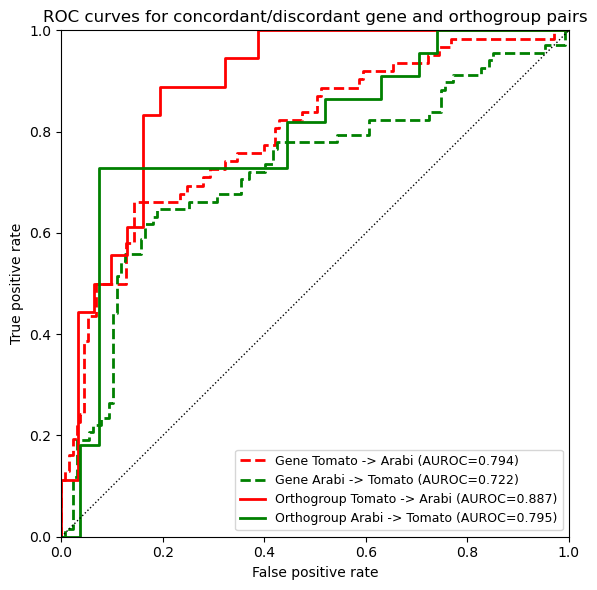

In [56]:
plot_colors = {
    "Tomato -> Arabi": "red",
    "Arabi -> Tomato": "green",
}
plot_linestyles = {
    "Orthogroup": "-",
    "Gene": "--",
}

plt.figure(figsize=(6, 6))
for _, summary_row in bidirectional_auroc_summary.iterrows():
    curve_subset = bidirectional_roc_curves.loc[
        (bidirectional_roc_curves["pair_type"] == summary_row["pair_type"])
        & (
            bidirectional_roc_curves["prediction_direction"]
            == summary_row["prediction_direction"]
        )
    ]
    plt.plot(
        curve_subset["fpr"],
        curve_subset["tpr"],
        color=plot_colors[summary_row["prediction_direction"]],
        linestyle=plot_linestyles[summary_row["pair_type"]],
        linewidth=2,
        label=(
            f"{summary_row['pair_type']} {summary_row['prediction_direction']} "
            f"(AUROC={summary_row['auroc']:.3f})"
        ),
    )

plt.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves for concordant/discordant gene and orthogroup pairs")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()

In [57]:
arabi_genes_trimmed

,index,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,soybean Symbol,brome Symbol
0,75178,82.992119,-1.024906,0.271418,-3.776114,1.592942e-04,4.399304e-04,GLYMA_14G133100,LOC100844744
1,77984,1619.499356,0.036739,0.111469,0.329591,7.417090e-01,7.931762e-01,GLYMA_09G136800,LOC100825490
2,29574,26.967880,0.143036,0.415414,0.344322,7.306040e-01,7.842962e-01,GLYMA_04G239600,LOC100837010
3,26492,55.700845,0.491332,0.346797,1.416771,1.565498e-01,2.151814e-01,GLYMA_10G230100,LOC100837316
4,23910,489.816053,0.417651,0.120687,3.460609,5.389545e-04,1.339281e-03,GLYMA_09G224100,LOC100821843
...,...,...,...,...,...,...,...,...,...
7585,55185,2069.182604,0.118442,0.136501,0.867700,3.855588e-01,4.646159e-01,GLYMA_10G283400,LOC100838433
7586,43973,1422.422605,-0.865280,0.115142,-7.514929,5.694194e-14,5.814770e-13,GLYMA_13G357200,LOC100845152
7587,77813,2142.851788,0.565383,0.157690,3.585411,3.365477e-04,8.703181e-04,GLYMA_12G228700,LOC100839049
7588,45655,315.018439,0.042993,0.150568,0.285541,7.752298e-01,8.209775e-01,GLYMA_08G002800,LOC100846573


In [59]:
def get_ncbi_clean_og2gene_for_species(
    species_1, og2genes_only_cococonet, ncbi_mapping
):

    species_1_name = species_1

    first_species_ortho_groups = og2genes_only_cococonet.loc[
        og2genes_only_cococonet["Species"] == species_1
    ]
    shared_orthogroups = first_species_ortho_groups["Orthogroup"].unique()

    list_of_orthogene_pds = []
    for orthogroup in tq.tqdm(
        shared_orthogroups, desc="inner_loop", position=0, leave=False
    ):
        species_1_genes = (
            first_species_ortho_groups["Gene"]
            .loc[first_species_ortho_groups["Orthogroup"] == orthogroup]
            .to_list()
        )
        all_gene_combos = species_1_genes
        current_orthogroup_pd = pd.DataFrame(
            columns=[f"{species_1_name} OrthoGene"], data=all_gene_combos
        )
        current_orthogroup_pd["Orthogroup"] = orthogroup
        list_of_orthogene_pds.append(current_orthogroup_pd)

    final_species_lineup = pd.concat(list_of_orthogene_pds)
    ncbi_added_once = final_species_lineup.merge(
        right=ncbi_mapping[["Orthodb Gene", "Symbol"]],
        right_on="Orthodb Gene",
        left_on=f"{species_1_name} OrthoGene",
    )
    ncbi_added_once_clean = ncbi_added_once.drop(columns="Orthodb Gene")
    return ncbi_added_once_clean
og_groups = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/og_2_Genes_with_ncbi_symbol.csv"
)
og_groups
ncbi_mapping = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/merged_ncbi_to_orthodb_fixed_non_genesymbol.csv"
)

In [61]:
import tqdm as tq
arabi_og = get_ncbi_clean_og2gene_for_species(
    15368, og_groups, ncbi_mapping=ncbi_mapping
)

inner_loop:   0%|          | 0/14996 [00:00<?, ?it/s]

In [75]:
arabi_genes_trimmed

,index,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,soybean Symbol,brome Symbol
0,75178,82.992119,-1.024906,0.271418,-3.776114,1.592942e-04,4.399304e-04,GLYMA_14G133100,LOC100844744
1,77984,1619.499356,0.036739,0.111469,0.329591,7.417090e-01,7.931762e-01,GLYMA_09G136800,LOC100825490
2,29574,26.967880,0.143036,0.415414,0.344322,7.306040e-01,7.842962e-01,GLYMA_04G239600,LOC100837010
3,26492,55.700845,0.491332,0.346797,1.416771,1.565498e-01,2.151814e-01,GLYMA_10G230100,LOC100837316
4,23910,489.816053,0.417651,0.120687,3.460609,5.389545e-04,1.339281e-03,GLYMA_09G224100,LOC100821843
...,...,...,...,...,...,...,...,...,...
7585,55185,2069.182604,0.118442,0.136501,0.867700,3.855588e-01,4.646159e-01,GLYMA_10G283400,LOC100838433
7586,43973,1422.422605,-0.865280,0.115142,-7.514929,5.694194e-14,5.814770e-13,GLYMA_13G357200,LOC100845152
7587,77813,2142.851788,0.565383,0.157690,3.585411,3.365477e-04,8.703181e-04,GLYMA_12G228700,LOC100839049
7588,45655,315.018439,0.042993,0.150568,0.285541,7.752298e-01,8.209775e-01,GLYMA_08G002800,LOC100846573


In [84]:
merged_gene_df = (
    arabi_genes_trimmed.rename(columns={"log2FoldChange": "Arabidopsis Log2FC"})
    [["brome Symbol", "Arabidopsis Log2FC"]]
    .merge(
        right=arabi_og[["Symbol", "Orthogroup"]].drop_duplicates(
            subset="Symbol", keep="first"
        ),
        left_on="brome Symbol",
        right_on="Symbol",
        how="left",
    )
    .drop(columns="Symbol")
    .merge(
        right=tomato_genes_trimmed.rename(
            columns={"log2FoldChange": "Tomato Log2FC"}
        )[["brome Symbol", "Tomato Log2FC"]],
        on="brome Symbol",
        how="inner",
    )
    [["Orthogroup", "brome Symbol", "Arabidopsis Log2FC", "Tomato Log2FC"]]
    .set_index("brome Symbol")
)

merged_gene_df

,Orthogroup,Arabidopsis Log2FC,Tomato Log2FC
brome Symbol,,,
LOC100844744,888374at3193,-1.024906,0.861340
LOC100825490,889869at3193,0.036739,-0.144485
LOC100837010,4223at3193,0.143036,-0.067016
LOC100837316,338866at3193,0.491332,0.596413
LOC100821843,291992at3193,0.417651,0.065794
...,...,...,...
LOC100838433,868926at3193,0.118442,0.599615
LOC100845152,744894at3193,-0.865280,-1.570305
LOC100839049,889810at3193,0.565383,0.173071


In [80]:
merged_gene_df

,Orthogroup,Log2FC,Tomato Log2FC
brome Symbol,,,
LOC100844744,888374at3193,-1.024906,0.861340
LOC100825490,889869at3193,0.036739,-0.144485
LOC100837010,4223at3193,0.143036,-0.067016
LOC100837316,338866at3193,0.491332,0.596413
LOC100821843,291992at3193,0.417651,0.065794
...,...,...,...
LOC100838433,868926at3193,0.118442,0.599615
LOC100845152,744894at3193,-0.865280,-1.570305
LOC100839049,889810at3193,0.565383,0.173071


In [82]:
merged_ortho_df

,Arabidopsis Log2FC,baseMean,Tomato Log2FC,lfcSE,stat,pvalue,padj
10772at3193,-0.823722,1432.514851,0.141324,0.096395,1.466092,1.426233e-01,2.167360e-01
10950at3193,0.609257,1504.589985,0.768931,0.130069,5.911713,3.385688e-09,2.105629e-08
109808at3193,-0.234491,81.928350,-0.724654,0.321686,-2.252679,2.427938e-02,4.721166e-02
109895at3193,-0.965963,34.756034,0.141902,0.317448,0.447008,6.548695e-01,7.391474e-01
109989at3193,-0.085234,438.013716,-0.142711,0.125299,-1.138971,2.547153e-01,3.491290e-01
...,...,...,...,...,...,...,...
9592at3193,-0.088107,714.567831,-1.004056,0.114738,-8.750851,2.117501e-18,3.047359e-17
9601at3193,0.012267,555.019544,-0.245262,0.172802,-1.419321,1.558055e-01,2.330127e-01
9609at3193,-2.083956,180.978946,-1.038789,0.284603,-3.649957,2.622840e-04,7.823873e-04
9789at3193,-0.323663,642.577002,-0.762086,0.124106,-6.140625,8.219721e-10,5.552505e-09


In [85]:
gene_threshold = 1.5

merged_gene_df_arabi_threshold = merged_gene_df.loc[
    merged_gene_df["Arabidopsis Log2FC"].abs() > gene_threshold
] .copy()

merged_gene_df_arabi_threshold["Orthogroup Arabidopsis Log2FC"] = merged_gene_df_arabi_threshold[
    "Orthogroup"
] .map(merged_ortho_df["Arabidopsis Log2FC"] )

merged_gene_df_arabi_threshold[
    "Orthogroup exceeds Arabidopsis threshold in same direction"
] = (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] > gene_threshold)
    & (merged_gene_df_arabi_threshold["Orthogroup Arabidopsis Log2FC"] > gene_threshold)
) | (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] < -gene_threshold)
    & (merged_gene_df_arabi_threshold["Orthogroup Arabidopsis Log2FC"] < -gene_threshold)
)

merged_gene_df_arabi_threshold

,Orthogroup,Arabidopsis Log2FC,Tomato Log2FC,Orthogroup Arabidopsis Log2FC,Orthogroup exceeds Arabidopsis threshold in same direction
brome Symbol,,,,,
LOC104582101,80999at3193,-1.800532,-0.381228,NaN,False
LOC100825155,885429at3193,-1.796314,1.753563,-0.332221,False
LOC100824036,883391at3193,-1.827832,-1.533943,NaN,False
LOC100833957,2434at3193,-1.585870,0.234226,NaN,False
LOC100831992,115032at3193,1.568969,0.278181,0.550427,False
...,...,...,...,...,...
LOC100846880,115323at3193,2.254765,1.720216,NaN,False
LOC100821370,888273at3193,-2.774071,-1.362765,NaN,False
LOC100821992,332503at3193,-2.065125,-1.891005,NaN,False


In [86]:
merged_gene_df_arabi_threshold[
    "Tomato exceeds threshold in same direction"
 ] = (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] > gene_threshold)
    & (merged_gene_df_arabi_threshold["Tomato Log2FC"] > gene_threshold)
) | (
    (merged_gene_df_arabi_threshold["Arabidopsis Log2FC"] < -gene_threshold)
    & (merged_gene_df_arabi_threshold["Tomato Log2FC"] < -gene_threshold)
)

merged_gene_df_arabi_threshold

,Orthogroup,Arabidopsis Log2FC,Tomato Log2FC,Orthogroup Arabidopsis Log2FC,Orthogroup exceeds Arabidopsis threshold in same direction,Tomato exceeds threshold in same direction
brome Symbol,,,,,,
LOC104582101,80999at3193,-1.800532,-0.381228,NaN,False,False
LOC100825155,885429at3193,-1.796314,1.753563,-0.332221,False,False
LOC100824036,883391at3193,-1.827832,-1.533943,NaN,False,True
LOC100833957,2434at3193,-1.585870,0.234226,NaN,False,False
LOC100831992,115032at3193,1.568969,0.278181,0.550427,False,False
...,...,...,...,...,...,...
LOC100846880,115323at3193,2.254765,1.720216,NaN,False,True
LOC100821370,888273at3193,-2.774071,-1.362765,NaN,False,False
LOC100821992,332503at3193,-2.065125,-1.891005,NaN,False,True


In [87]:
fisher_input_df = merged_gene_df_arabi_threshold[[
    "Orthogroup exceeds Arabidopsis threshold in same direction",
    "Tomato exceeds threshold in same direction",
]].copy()

fisher_contingency_table = pd.crosstab(
    fisher_input_df["Orthogroup exceeds Arabidopsis threshold in same direction"],
    fisher_input_df["Tomato exceeds threshold in same direction"],
).reindex(index=[False, True], columns=[False, True], fill_value=0)

fisher_odds_ratio, fisher_p_value = stats.fisher_exact(
    fisher_contingency_table.to_numpy(),
    alternative="greater",
)

fisher_exact_summary = pd.DataFrame(
    {
        "odds_ratio": [fisher_odds_ratio],
        "p_value": [fisher_p_value],
    }
)

fisher_contingency_table, fisher_exact_summary

(Tomato exceeds threshold in same direction          False  True 
 Orthogroup exceeds Arabidopsis threshold in sam...              
 False                                                 413    118
 True                                                   61     29,
    odds_ratio   p_value
 0    1.663934  0.029248)

In [88]:
readable_fisher_table = fisher_contingency_table.rename(
    index={
        False: "Orthogroup below / opposite direction",
        True: "Orthogroup exceeds in same direction",
    },
    columns={
        False: "Tomato below / opposite direction",
        True: "Tomato exceeds in same direction",
    },
)

readable_fisher_table["Row total"] = readable_fisher_table.sum(axis=1)
readable_fisher_table.loc["Column total"] = readable_fisher_table.sum(axis=0)

readable_fisher_table

Tomato exceeds threshold in same direction,Tomato below / opposite direction,Tomato exceeds in same direction,Row total
Orthogroup exceeds Arabidopsis threshold in same direction,,,
Orthogroup below / opposite direction,413,118,531
Orthogroup exceeds in same direction,61,29,90
Column total,474,147,621


In [89]:
fisher_same_vs_opposite_df = merged_gene_df_arabi_threshold[[
    "Orthogroup exceeds Arabidopsis threshold in same direction",
    "Arabidopsis Log2FC",
    "Tomato Log2FC",
]].copy()

fisher_same_vs_opposite_df["Tomato in same direction"] = (
    fisher_same_vs_opposite_df["Arabidopsis Log2FC"]
    * fisher_same_vs_opposite_df["Tomato Log2FC"]
    > 0
)

fisher_same_vs_opposite_table = pd.crosstab(
    fisher_same_vs_opposite_df[
        "Orthogroup exceeds Arabidopsis threshold in same direction"
    ],
    fisher_same_vs_opposite_df["Tomato in same direction"],
).reindex(index=[False, True], columns=[False, True], fill_value=0)

fisher_same_vs_opposite_odds_ratio, fisher_same_vs_opposite_p_value = stats.fisher_exact(
    fisher_same_vs_opposite_table.to_numpy(),
    alternative="greater",
)

fisher_same_vs_opposite_summary = pd.DataFrame(
    {
        "odds_ratio": [fisher_same_vs_opposite_odds_ratio],
        "p_value": [fisher_same_vs_opposite_p_value],
    }
)

readable_fisher_same_vs_opposite_table = fisher_same_vs_opposite_table.rename(
    index={
        False: "Orthogroup below / opposite direction",
        True: "Orthogroup exceeds in same direction",
    },
    columns={
        False: "Tomato in opposite direction",
        True: "Tomato in same direction",
    },
)

readable_fisher_same_vs_opposite_table["Row total"] = (
    readable_fisher_same_vs_opposite_table.sum(axis=1)
)
readable_fisher_same_vs_opposite_table.loc["Column total"] = (
    readable_fisher_same_vs_opposite_table.sum(axis=0)
)

readable_fisher_same_vs_opposite_table, fisher_same_vs_opposite_summary

(Tomato in same direction                            Tomato in opposite direction  \
 Orthogroup exceeds Arabidopsis threshold in sam...                                 
 Orthogroup below / opposite direction                                        190   
 Orthogroup exceeds in same direction                                          25   
 Column total                                                                 215   
 
 Tomato in same direction                            Tomato in same direction  \
 Orthogroup exceeds Arabidopsis threshold in sam...                             
 Orthogroup below / opposite direction                                    341   
 Orthogroup exceeds in same direction                                      65   
 Column total                                                             406   
 
 Tomato in same direction                            Row total  
 Orthogroup exceeds Arabidopsis threshold in sam...             
 Orthogroup below / opposite directi

In [90]:
non_missing_orthogroup_df = merged_gene_df_arabi_threshold.dropna(
    subset=["Orthogroup Arabidopsis Log2FC"]
 ).copy()

non_missing_fisher_input_df = non_missing_orthogroup_df[[
    "Orthogroup exceeds Arabidopsis threshold in same direction",
    "Tomato exceeds threshold in same direction",
]].copy()

non_missing_fisher_contingency_table = pd.crosstab(
    non_missing_fisher_input_df[
        "Orthogroup exceeds Arabidopsis threshold in same direction"
    ],
    non_missing_fisher_input_df["Tomato exceeds threshold in same direction"],
).reindex(index=[False, True], columns=[False, True], fill_value=0)

non_missing_fisher_odds_ratio, non_missing_fisher_p_value = stats.fisher_exact(
    non_missing_fisher_contingency_table.to_numpy(),
    alternative="greater",
)

non_missing_fisher_summary = pd.DataFrame(
    {
        "odds_ratio": [non_missing_fisher_odds_ratio],
        "p_value": [non_missing_fisher_p_value],
        "n_genes": [len(non_missing_orthogroup_df)],
    }
)

readable_non_missing_fisher_table = non_missing_fisher_contingency_table.rename(
    index={
        False: "Orthogroup below / opposite direction",
        True: "Orthogroup exceeds in same direction",
    },
    columns={
        False: "Tomato below / opposite direction",
        True: "Tomato exceeds in same direction",
    },
)

readable_non_missing_fisher_table["Row total"] = readable_non_missing_fisher_table.sum(
    axis=1
)
readable_non_missing_fisher_table.loc["Column total"] = readable_non_missing_fisher_table.sum(
    axis=0
)

display(readable_non_missing_fisher_table)
non_missing_fisher_summary

Tomato exceeds threshold in same direction,Tomato below / opposite direction,Tomato exceeds in same direction,Row total
Orthogroup exceeds Arabidopsis threshold in same direction,,,
Orthogroup below / opposite direction,133,23,156
Orthogroup exceeds in same direction,61,29,90
Column total,194,52,246


,odds_ratio,p_value,n_genes
0,2.749109,0.001221,246


In [ ]:
all_under_1

In [ ]:
merged_result

In [ ]:
merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

pos_thresh = 0
neg_thresh = 0
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

In [ ]:
stats.spearmanr(a=tomato_genes_trimmed['log2FoldChange'], b = arabi_genes_trimmed['log2FoldChange'] )

In [ ]:
down = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] <= -2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
up = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] >= 2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
down_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] <= -2)
    & (arabi_genes_trimmed["padj"] <= 0.001)
]
up_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] >= 2) & (arabi_genes_trimmed["padj"] <= 0.001)
]

In [ ]:
down_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] <= -2)
    & (trimmed_arabi_ortho["padj"] <= 0.001)
]
up_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] >= 2) & (trimmed_arabi_ortho["padj"] <= 0.001)]

down_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] <= -2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]
up_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] >= 2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]

In [ ]:
len(up_arabi_ortho.merge(how = "inner", right_index = True, left_index= True, right = up_ortho))

In [ ]:
up_ortho

In [ ]:
up_arabi_ortho

In [ ]:
up

In [ ]:
up_arabi

In [ ]:
up_arabi.merge(how = "inner", on = 'arabidopsis Symbol', right = up)